# CatBoost — Efeitos dos Atributos via SHAP

Este notebook mensura o impacto de cada atributo no desfecho do sinistro (`grave`)
usando **SHAP Global E[φ_k]** como medida de efeito.

O SHAP é calculado na **escala de probabilidade**, garantindo comparabilidade
direta com os **AMEs da regressão logística**: ambos expressam a variação média
em P(grave = 1) atribuída a cada variável.

> **Especificidade do CatBoost:** o CatBoost possui implementação nativa de SHAP
> via `get_feature_importance(type='ShapValues')`, retornando tensor 3D que inclui
> o viés na última coluna. Adota-se aqui o `TreeExplainer` do SHAP com
> `model_output="probability"` para manter consistência metodológica com o RF.
> Variáveis categóricas são passadas diretamente ao CatBoost (sem encoding prévio).


In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


c:\Users\Diego\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Carga dos dados

In [2]:
URL_TRAIN = "../../database/completo/final/df_train.csv"
URL_TEST  = "../../database/completo/final/df_test.csv"

df_train = pd.read_csv(URL_TRAIN, encoding="UTF-8")
df_test  = pd.read_csv(URL_TEST,  encoding="UTF-8")

X_train = df_train.drop(columns=["grave", "ano"])
y_train = df_train["grave"]

X_test = df_test.drop(columns=["grave", "ano"])
y_test = df_test["grave"]

print(f"Treino : {X_train.shape}  |  Teste: {X_test.shape}")


Treino : (558847, 20)  |  Teste: (72310, 20)


In [18]:
df_train.columns

Index(['sentido_via', 'pista_molhada', 'visibilidade_ruim', 'tipo_pista',
       'uso_solo', 'intersecao_de_vias', 'reta', 'declive',
       'condicao_ignorada', 'feriado', 'ano', 'vel_max', 'distancia_radar_m',
       'frequencia', 'grave', 'uf_br_km', 'turno_sin', 'turno_cos',
       'dia_semana_sin', 'dia_semana_cos', 'mes_sin', 'mes_cos'],
      dtype='object')

## 2. Treinamento — CatBoost

In [3]:
from catboost import CatBoostClassifier

# CatBoost aceita categóricas diretamente; identifica-as pelo dtype object.
cat_features = [col for col in X_train.columns if X_train[col].dtype == object]
cat_indices  = [X_train.columns.get_loc(c) for c in cat_features]

# CatBoost exige string (não NaN) nas colunas categóricas
for col in cat_features:
    X_train[col] = X_train[col].astype(str).fillna("missing")
    X_test[col]  = X_test[col].astype(str).fillna("missing")

print(f"Colunas categóricas ({len(cat_features)}): {cat_features}")

# Desbalanceamento via scale_pos_weight — equivalente ao class_weight='balanced'
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos

print(f"Desbalanceamento — negativos: {n_neg:,} | positivos: {n_pos:,}")
print(f"scale_pos_weight = {scale_pos_weight:.2f}")

cat = CatBoostClassifier(
    iterations=300,
    depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric="AUC",
    cat_features=cat_indices,
    random_seed=42,
    verbose=0
)
cat.fit(X_train, y_train)
print("Modelo treinado.")


Colunas categóricas (0): []
Desbalanceamento — negativos: 486,401 | positivos: 72,446
scale_pos_weight = 6.71
Modelo treinado.


## 3. Avaliação no conjunto de teste

In [4]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

y_pred = cat.predict(X_test)
y_prob = cat.predict_proba(X_test)[:, 1]

print("=== Métricas (Teste 2025) ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1-score : {f1_score(y_test, y_pred):.4f}")
print(f"AUC      : {roc_auc_score(y_test, y_prob):.4f}")
print()
print(classification_report(y_test, y_pred))


=== Métricas (Teste 2025) ===
Accuracy : 0.6375
Precision: 0.1852
Recall   : 0.4616
F1-score : 0.2644
AUC      : 0.5756

              precision    recall  f1-score   support

           0       0.88      0.67      0.76     62109
           1       0.19      0.46      0.26     10201

    accuracy                           0.64     72310
   macro avg       0.53      0.56      0.51     72310
weighted avg       0.78      0.64      0.69     72310



## 4. SHAP na escala de probabilidade

In [5]:
X_background  = shap.sample(X_train, 500, random_state=42)
X_test_sample = X_test.sample(min(5000, len(X_test)), random_state=42)
n_obs, n_features = X_test_sample.shape

explainer = shap.TreeExplainer(
    cat,
    data=X_background,
    model_output="probability",
    feature_perturbation="interventional"
)

print("Calculando SHAP values...")
shap_values = explainer.shap_values(X_test_sample)
raw = np.array(shap_values)
print(f"Formato bruto: {raw.shape}")

# ── Normaliza para (n_obs, n_features) — classe 1 ──────────────────
if isinstance(shap_values, list):
    shap_array     = np.array(shap_values[1])
    expected_value = explainer.expected_value[1]
elif raw.ndim == 3 and raw.shape[0] == 2:
    shap_array     = raw[1]
    expected_value = explainer.expected_value[1]
elif raw.ndim == 3 and raw.shape[2] == 2:
    shap_array     = raw[:, :, 1]
    expected_value = explainer.expected_value[1]
else:
    shap_array     = raw
    expected_value = (explainer.expected_value[1]
                      if hasattr(explainer.expected_value, '__len__')
                      else explainer.expected_value)

if shap_array.shape == (n_features, n_obs):
    print("[AVISO] array transposto detectado — corrigindo.")
    shap_array = shap_array.T

print(f"Formato final: {shap_array.shape}")
print(f"φ_0 (valor esperado): {expected_value:.6f}")


Calculando SHAP values...


 99%|===================| 4945/5000 [01:01<00:00]        

Formato bruto: (5000, 20)
Formato final: (5000, 20)
φ_0 (valor esperado): 0.375300


### 4.1 Validação formal da escala de probabilidade

In [6]:
# ─────────────────────────────────────────────────────────────────────
# Propriedade de eficiência (Lundberg e Lee, 2017):
#   φ_0 + Σ_k φ_k(i) = P(grave=1 | X=xᵢ)
#
# O CatBoost honra model_output="probability" no TreeExplainer de forma
# mais consistente que o sklearn RF. Ainda assim, a verificação abaixo
# é necessária para garantir a comparabilidade com os AMEs (Rodrigues, 2026b).
# ─────────────────────────────────────────────────────────────────────
prob_real          = cat.predict_proba(X_test_sample)[:, 1]
shap_reconstructed = expected_value + shap_array.sum(axis=1)

desvios  = np.abs(shap_reconstructed - prob_real)
max_dev  = desvios.max()
mean_dev = desvios.mean()
p95_dev  = np.percentile(desvios, 95)

print("=== Verificação da propriedade de eficiência ===")
print(f"  φ_0 + Σφ_k(i) ≈ P̂(i)  ?")
print(f"  Desvio máximo   : {max_dev:.2e}")
print(f"  Desvio médio    : {mean_dev:.2e}")
print(f"  Percentil 95    : {p95_dev:.2e}")
print()

if max_dev < 1e-3:
    print("[OK] Escala de probabilidade confirmada.")
    print("     Os SHAP values são diretamente comparáveis aos AMEs da regressão logística.")
    print(f"     Intervalo de φ_k: [{shap_array.min():.4f}, {shap_array.max():.4f}]")
    print(f"     Soma média dos φ_k: {shap_array.sum(axis=1).mean():.4f}")
else:
    print("[ERRO] TreeExplainer não está operando na escala de probabilidade.")
    print("       Substitua por KernelExplainer com wrapper de predict_proba:")
    print()
    print("       def predict_proba_cat(X):")
    print("           return cat.predict_proba(X)[:, 1]")
    print("       X_bg      = shap.kmeans(X_train, 100)")
    print("       explainer = shap.KernelExplainer(predict_proba_cat, X_bg)")
    print("       shap_values = explainer.shap_values(X_test_sample, silent=True)")
    print("       shap_array  = np.array(shap_values)")
    print("       expected_value = explainer.expected_value")


=== Verificação da propriedade de eficiência ===
  φ_0 + Σφ_k(i) ≈ P̂(i)  ?
  Desvio máximo   : 6.25e-09
  Desvio médio    : 9.85e-10
  Percentil 95    : 2.66e-09

[OK] Escala de probabilidade confirmada.
     Os SHAP values são diretamente comparáveis aos AMEs da regressão logística.
     Intervalo de φ_k: [-0.3374, 0.5836]
     Soma média dos φ_k: 0.0440


## 5. SHAP Global — E[φ_k]

In [7]:
shap_global_mean = pd.Series(
    shap_array.mean(axis=0),
    index=X_test_sample.columns,
    name="SHAP_global_E[phi_k]"
)
shap_global_abs = pd.Series(
    np.abs(shap_array).mean(axis=0),
    index=X_test_sample.columns,
    name="SHAP_importancia_E[|phi_k|]"
)

resultado = pd.concat([shap_global_mean, shap_global_abs], axis=1)
resultado = resultado.sort_values("SHAP_importancia_E[|phi_k|]", ascending=False)

print("=== Impacto dos atributos — CatBoost ===")
print("E[φ_k]   → efeito médio com sinal, em unidades de probabilidade")
print("E[|φ_k|] → importância absoluta, para ranqueamento")
print()
print(resultado.to_string(float_format="{:.6f}".format))


=== Impacto dos atributos — CatBoost ===
E[φ_k]   → efeito médio com sinal, em unidades de probabilidade
E[|φ_k|] → importância absoluta, para ranqueamento

                    SHAP_global_E[phi_k]  SHAP_importancia_E[|phi_k|]
uf_br_km                        0.038960                     0.159667
vel_max                         0.005891                     0.041832
frequencia                      0.004300                     0.018829
turno_sin                      -0.003698                     0.017795
uso_solo                       -0.000289                     0.015890
tipo_pista                     -0.003132                     0.014403
distancia_radar_m              -0.000097                     0.009178
turno_cos                      -0.001672                     0.008982
pista_molhada                   0.002467                     0.007410
dia_semana_sin                 -0.000303                     0.005677
declive                         0.000326                     0.005608
vis

## 6. Visualizações globais

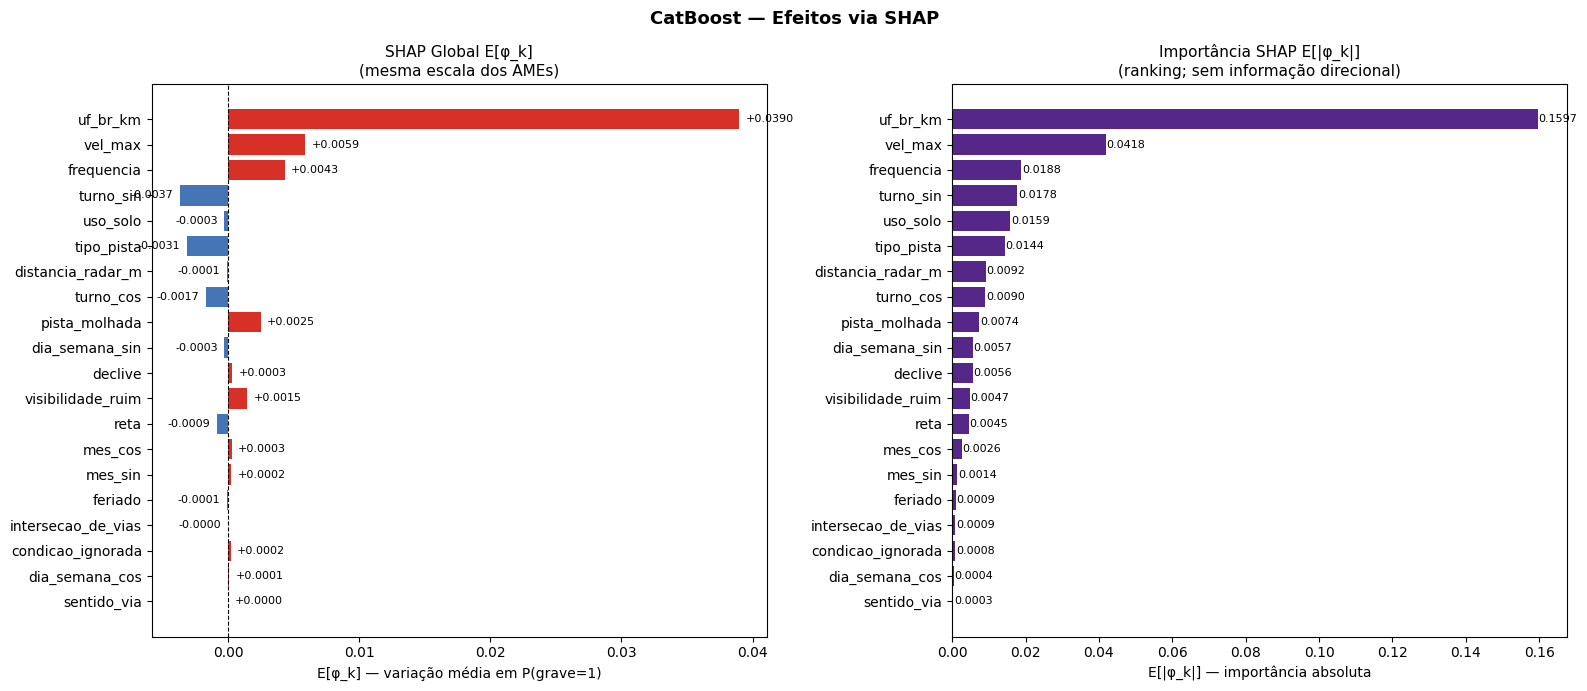

Gráfico salvo em catboost_shap_efeitos.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("CatBoost — Efeitos via SHAP", fontsize=13, fontweight='bold')

# ── Gráfico 1: E[φ_k] com sinal ─────────────────────────────────────
cores = ['#d73027' if v > 0 else '#4575b4' for v in resultado["SHAP_global_E[phi_k]"]]
bars1 = axes[0].barh(resultado.index, resultado["SHAP_global_E[phi_k]"], color=cores)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel("E[φ_k] — variação média em P(grave=1)")
axes[0].set_title("SHAP Global E[φ_k]\n(mesma escala dos AMEs)", fontsize=11)
axes[0].invert_yaxis()

for bar, val in zip(bars1, resultado["SHAP_global_E[phi_k]"]):
    axes[0].text(
        bar.get_width() + (0.0005 if val >= 0 else -0.0005),
        bar.get_y() + bar.get_height() / 2,
        f"{val:+.4f}", va='center',
        ha='left' if val >= 0 else 'right', fontsize=8
    )

# ── Gráfico 2: E[|φ_k|] (ranking) ───────────────────────────────────
bars2 = axes[1].barh(resultado.index, resultado["SHAP_importancia_E[|phi_k|]"],
                     color='#542788')
axes[1].set_xlabel("E[|φ_k|] — importância absoluta")
axes[1].set_title("Importância SHAP E[|φ_k|]\n(ranking; sem informação direcional)",
                  fontsize=11)
axes[1].invert_yaxis()

for bar, val in zip(bars2, resultado["SHAP_importancia_E[|phi_k|]"]):
    axes[1].text(
        bar.get_width() + 0.0002,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}", va='center', ha='left', fontsize=8
    )

plt.tight_layout()
plt.savefig("catboost_shap_efeitos.png", dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo em catboost_shap_efeitos.png")


### 6.1 Beeswarm — distribuição local dos φ_k(i)

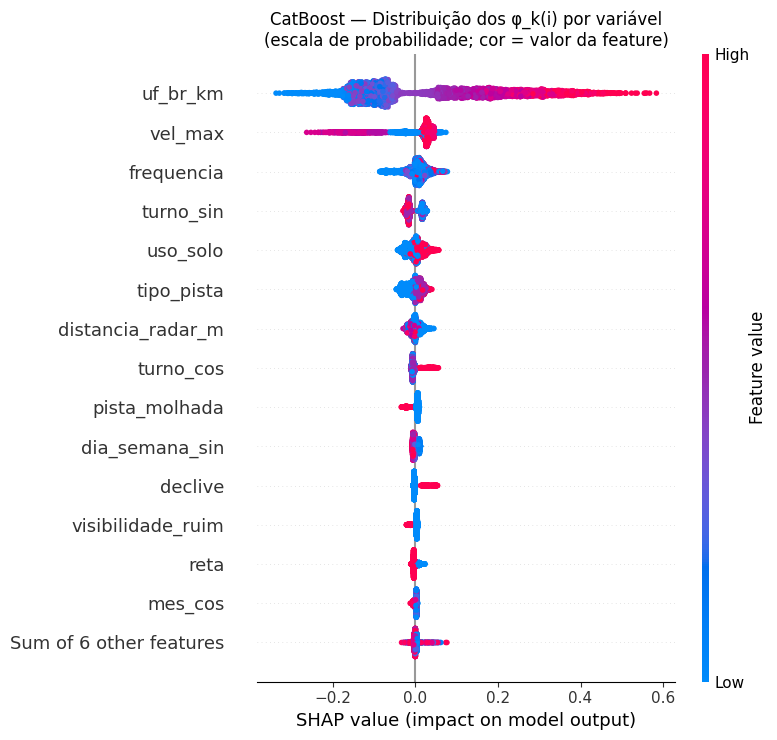

Beeswarm salvo em catboost_shap_beeswarm.png


In [9]:
shap_explanation = shap.Explanation(
    values=shap_array,
    base_values=expected_value,
    data=X_test_sample.values,
    feature_names=list(X_test_sample.columns)
)

plt.figure()
shap.plots.beeswarm(shap_explanation, max_display=15, show=False)
plt.title("CatBoost — Distribuição dos φ_k(i) por variável\n"
          "(escala de probabilidade; cor = valor da feature)")
plt.tight_layout()
plt.savefig("catboost_shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.show()
print("Beeswarm salvo em catboost_shap_beeswarm.png")


### 6.2 Waterfall — decomposição de uma observação individual

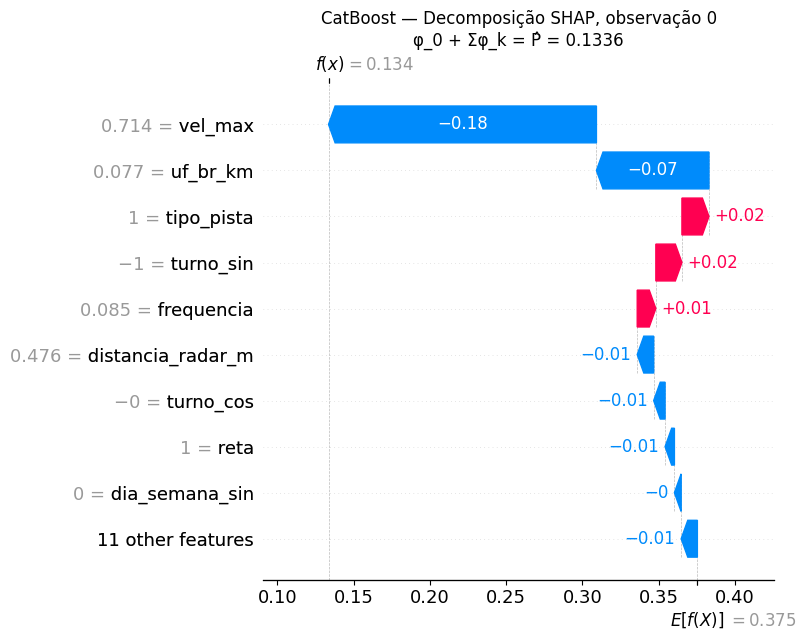

Waterfall salvo em catboost_shap_waterfall.png


In [10]:
idx = 0

plt.figure()
shap.plots.waterfall(shap_explanation[idx], show=False)
plt.title(f"CatBoost — Decomposição SHAP, observação {idx}\n"
          f"φ_0 + Σφ_k = P̂ = {expected_value + shap_array[idx].sum():.4f}")
plt.tight_layout()
plt.savefig("catboost_shap_waterfall.png", dpi=150, bbox_inches='tight')
plt.show()
print("Waterfall salvo em catboost_shap_waterfall.png")


## 7. Análise das variáveis cíclicas

As variáveis temporais (turno, dia_semana, mes) foram codificadas via sin/cos encoding.
Para interpretá-las via SHAP é necessário recombinar os dois componentes e projetá-los
sobre cada posição do ciclo original.


In [11]:
# ─────────────────────────────────────────────────────────────────────
# Utilitários para análise e visualização de variáveis ciclicas
# (turno, dia_semana, mes) codificadas via sin/cos encoding.
# ─────────────────────────────────────────────────────────────────────

def cyclic_importance(shap_array, X, sin_name, cos_name):
    """
    Métricas de importância para um par sin/cos de variável cíclica.

    Retorna:
        importance_cyclic  : E[sqrt(φ_sin² + φ_cos²)]  — análogo a E[|φ|]
        direction_amplitude: amplitude do vetor médio — indica efeito sistêmico
        mean_sin / mean_cos: componentes do vetor médio
        variability        : desvio padrão de (φ_sin + φ_cos) — heterogeneidade
    """
    idx_sin = list(X.columns).index(sin_name)
    idx_cos = list(X.columns).index(cos_name)
    phi_sin = shap_array[:, idx_sin]
    phi_cos = shap_array[:, idx_cos]
    return {
        "importance_cyclic"  : float(np.mean(np.sqrt(phi_sin**2 + phi_cos**2))),
        "direction_amplitude": float(np.sqrt(np.mean(phi_sin)**2 + np.mean(phi_cos)**2)),
        "mean_sin"           : float(np.mean(phi_sin)),
        "mean_cos"           : float(np.mean(phi_cos)),
        "variability"        : float(np.std(phi_sin + phi_cos)),
    }


def plot_cyclic_effect(shap_array, X, sin_name, cos_name, labels, offset=0,
                       model_name="Modelo", save_path=None):
    """
    Projeta os SHAP values cíclicos sobre cada posição do ciclo e plota
    o efeito médio com rótulos de valor em cada ponto.

    Parâmetros:
        shap_array : array (n_obs, n_features) dos SHAP values (escala de prob.)
        X          : DataFrame com as colunas de features
        sin_name   : nome da coluna _sin  (ex: 'turno_sin')
        cos_name   : nome da coluna _cos  (ex: 'turno_cos')
        labels     : lista de rótulos para cada posição do ciclo
        offset     : ajuste de fase (1 para mês, 0 para os demais)
        model_name : nome do modelo para título do gráfico
        save_path  : caminho para salvar a figura (None = não salva)
    """
    period = len(labels)
    idx_sin = list(X.columns).index(sin_name)
    idx_cos = list(X.columns).index(cos_name)
    phi_sin = shap_array[:, idx_sin]
    phi_cos = shap_array[:, idx_cos]

    theta  = 2 * np.pi * (np.arange(period) - offset) / period
    effect = [np.mean(phi_sin * np.sin(t) + phi_cos * np.cos(t)) for t in theta]

    varname = sin_name.replace("_sin", "")

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(labels, effect, marker='o', linewidth=1.8, color='#2171b5')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.fill_between(range(period), effect, 0,
                    where=[e > 0 for e in effect], alpha=0.15, color='#d73027')
    ax.fill_between(range(period), effect, 0,
                    where=[e <= 0 for e in effect], alpha=0.15, color='#4575b4')

    # rótulo em cada ponto
    for i, (lbl, val) in enumerate(zip(labels, effect)):
        offset_y = 0.0003 if val >= 0 else -0.0003
        ax.annotate(
            f"{val:+.4f}",
            xy=(i, val), xytext=(0, 8 if val >= 0 else -14),
            textcoords='offset points',
            ha='center', fontsize=8, color='#222222'
        )

    ax.set_xticks(range(period))
    ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.set_xlabel("Posição no ciclo")
    ax.set_ylabel("Efeito médio SHAP — variação em P(grave=1)")
    ax.set_title(f"{model_name} — Efeito cíclico SHAP: {varname}\n"
                 f"(projeção dos φ_sin / φ_cos sobre cada posição)", fontsize=11)
    ax.grid(axis='y', linestyle=':', alpha=0.6)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Gráfico salvo em {save_path}")
    plt.show()


In [12]:
LABELS_TURNO    = ["Madrugada", "Manhã", "Tarde", "Noite"]
LABELS_SEMANA   = ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"]
LABELS_MES      = ["Jan", "Fev", "Mar", "Abr", "Mai", "Jun",
                   "Jul", "Ago", "Set", "Out", "Nov", "Dez"]


### 7.1 Métricas de importância cíclica

In [13]:
for sin_name, cos_name in [("turno_sin",     "turno_cos"),
                            ("dia_semana_sin","dia_semana_cos"),
                            ("mes_sin",       "mes_cos")]:
    varname = sin_name.replace("_sin", "")
    metrics = cyclic_importance(shap_array, X_test_sample, sin_name, cos_name)
    print(f"=== {varname} ===")
    for k, v in metrics.items():
        print(f"  {k:25s}: {v:.6f}")
    print()


=== turno ===
  importance_cyclic        : 0.021028
  direction_amplitude      : 0.004058
  mean_sin                 : -0.003698
  mean_cos                 : -0.001672
  variability              : 0.025933

=== dia_semana ===
  importance_cyclic        : 0.005714
  direction_amplitude      : 0.000309
  mean_sin                 : -0.000303
  mean_cos                 : 0.000061
  variability              : 0.006414

=== mes ===
  importance_cyclic        : 0.003189
  direction_amplitude      : 0.000336
  mean_sin                 : 0.000202
  mean_cos                 : 0.000269
  variability              : 0.003733



### 7.2 Efeito cíclico SHAP — Turno

Gráfico salvo em catboost_ciclo_turno.png


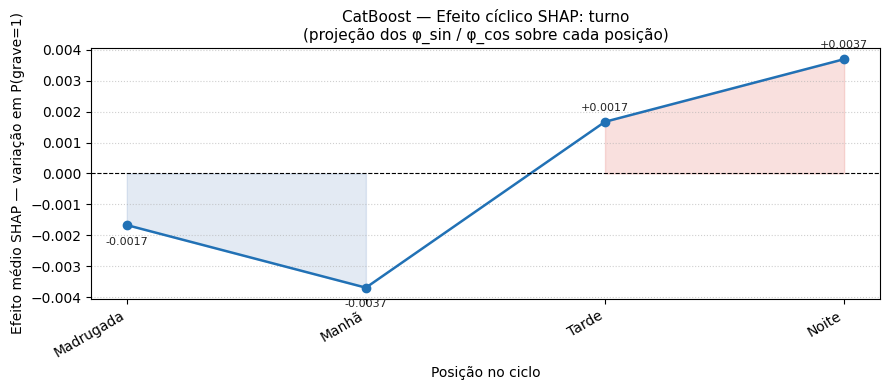

In [14]:
plot_cyclic_effect(
    shap_array, X_test_sample,
    "turno_sin", "turno_cos",
    labels=LABELS_TURNO,
    model_name="CatBoost",
    save_path="catboost_ciclo_turno.png"
)


### 7.3 Efeito cíclico SHAP — Dia da semana

Gráfico salvo em catboost_ciclo_dia_semana.png


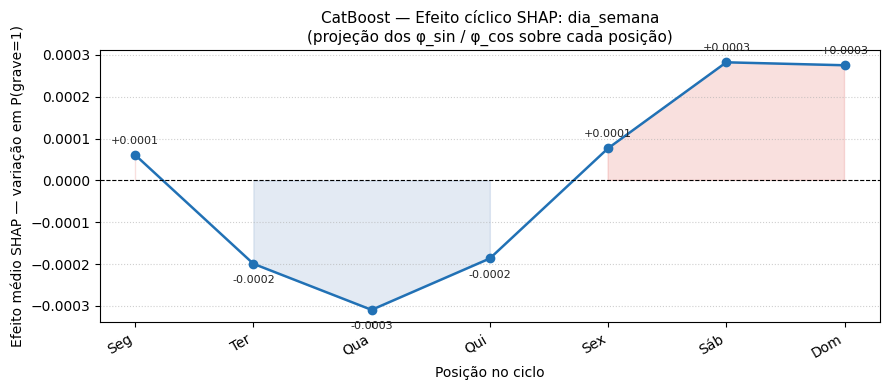

In [15]:
plot_cyclic_effect(
    shap_array, X_test_sample,
    "dia_semana_sin", "dia_semana_cos",
    labels=LABELS_SEMANA,
    model_name="CatBoost",
    save_path="catboost_ciclo_dia_semana.png"
)


### 7.4 Efeito cíclico SHAP — Mês

Gráfico salvo em catboost_ciclo_mes.png


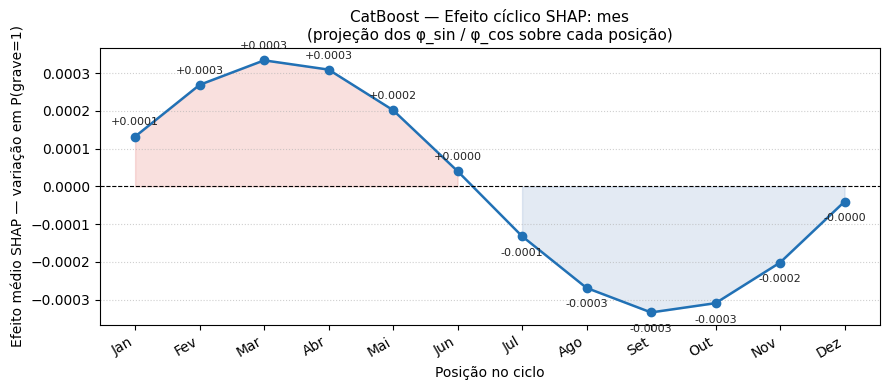

In [16]:
plot_cyclic_effect(
    shap_array, X_test_sample,
    "mes_sin", "mes_cos",
    labels=LABELS_MES,
    offset=1,
    model_name="CatBoost",
    save_path="catboost_ciclo_mes.png"
)


### 7.5 Interpretação dos efeitos cíclicos

**Como ler estes gráficos:**

- O eixo Y está em **unidades de probabilidade** — a mesma escala dos AMEs da
  regressão logística e dos gráficos globais E[φ_k].
- Um valor positivo em "Noite" significa que sinistros ocorridos à noite têm,
  em média, φ_k > 0 atribuído ao turno — i.e., o modelo associa esse período
  a maior probabilidade de desfecho grave, *ceteris paribus*.
- A área preenchida em vermelho indica posições onde o efeito aumenta a
  probabilidade de gravidade; azul indica redução.
- **Comparação com o Logit:** os gráficos equivalentes da regressão logística
  (seção 9 do notebook `logit_ame.ipynb`) seguem a mesma escala. Curvas
  coincidentes entre os três modelos indicam efeito robusto e linear; curvas
  divergentes indicam não linearidades capturadas apenas pelo ensemble.
